# Load Pfam labels and assess their spread on our dataset

- Counts observed in full dataset and test set
- Clans observed
- Metrics on test set across different families

## Load the HF dataset

In [10]:
import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('white')
sns.set_context('talk')

In [11]:
ds = datasets.load_from_disk('../data/dataset')

In [12]:
ds

DatasetDict({
    train: Dataset({
        features: ['meso_seq', 'thermo_seq', 'taxid', 'query_align_cov', 'subject_align_cov', 'bit_score', 'scaled_local_symmetric_percent_id', 'meso_seq_len', 'thermo_seq_len', 'seq_len_diff', 'meso_temp', 'thermo_temp', 'index', 'unique_seq_hash', 'cluster'],
        num_rows: 4013789
    })
    eval: Dataset({
        features: ['meso_seq', 'thermo_seq', 'taxid', 'query_align_cov', 'subject_align_cov', 'bit_score', 'scaled_local_symmetric_percent_id', 'meso_seq_len', 'thermo_seq_len', 'seq_len_diff', 'meso_temp', 'thermo_temp', 'index', 'unique_seq_hash', 'cluster'],
        num_rows: 303577
    })
    test: Dataset({
        features: ['meso_seq', 'thermo_seq', 'taxid', 'query_align_cov', 'subject_align_cov', 'bit_score', 'scaled_local_symmetric_percent_id', 'meso_seq_len', 'thermo_seq_len', 'seq_len_diff', 'meso_temp', 'thermo_temp', 'index', 'unique_seq_hash', 'cluster'],
        num_rows: 398140
    })
})

## get pfam labels (skip if run)

In [110]:
import glob
import pandas as pd
from pathlib import Path


# Get all domtblout files
domtblout_files = glob.glob("../data/pfam/scripts/domtblout_*.txt")

e_value_factor = len(domtblout_files)
# Dictionary to store query_id -> pfam mappings
query_to_pfams = {}

# Process each file
for file_path in domtblout_files:
    with open(file_path) as f:
        for line in f:
            # Skip comment lines
            if line.startswith('#'):
                # print(line)
                continue
            # Split line on whitespace

            fields = line.strip().split()
            if len(fields) < 4:  # Basic validation
                # print(fields)
                continue           

            

            # Fields in domtblout format
            # target_name query_name accession ...

            pfam_accession = fields[4]  # Pfam accession is in second column
            query_name = int(fields[0])      # Query name is in fourth column
            e = float(fields[12]) * e_value_factor
            
            if e >1e-3:
                continue
            # Add to dictionary
            if query_name not in query_to_pfams:
                query_to_pfams[query_name] = set()
            query_to_pfams[query_name].add(pfam_accession)

# Convert sets to semicolon-separated strings
final_data = {
    query_id: ';'.join(sorted(pfams))
    for query_id, pfams in query_to_pfams.items()
}

# Create DataFrame and save as parquet
df = pd.DataFrame.from_dict(
    final_data,
    orient='index',
    columns=['pfam_domains']
)
df.index.name = 'query_id'

# Save to parquet
output_path = "../data/index_to_pfam.parquet"

df.to_parquet(output_path)
print(f"Processed {len(domtblout_files)} files")

print(f"Found Pfam domains for {len(query_to_pfams)} unique queries")

print(f"Saved results to {output_path}")

 

# Display first few rows

print("\nFirst few rows of the dataset:")

print(df.head())

Processed 469 files
Found Pfam domains for 4662646 unique queries
Saved results to ../data/index_to_pfam.parquet

First few rows of the dataset:
                              pfam_domains
query_id                                  
2043842   PF00578.24;PF08534.13;PF10417.12
1522672                         PF04463.15
2997821                         PF01257.22
4089342                         PF01257.22
945921                PF02834.19;PF13563.9


### Get pfam counts and save (skip if run)

In [6]:
import pandas as pd

In [7]:
query_pfams = pd.read_parquet('../data/index_to_pfam.parquet')

In [16]:
(query_pfams == '').sum()

pfam_domains    0
dtype: int64

In [9]:
len(query_pfams)

4662646

In [115]:
pfam_counts = {}
for id_str in query_pfams['pfam_domains'].values:
    pfams = id_str.split(';')
    for pfam in pfams:
        if pfam not in pfam_counts:
            pfam_counts[pfam] = 1
        else:
            pfam_counts[pfam] += 1

In [116]:
len(pfam_counts)

2764

In [117]:
pfam35_size = 19632

In [118]:
print(len(pfam_counts)/pfam35_size)

0.14079054604726976


In [26]:
# save the counts such that we  can make a table
pd.Series(pfam_counts).to_csv('../data/pfam_all_counts.csv')

In [15]:
pfam_counts = pd.read_csv('../data/pfam_all_counts.csv')

In [19]:
# mark ones only in training set to see how many of the total we got
pf_in_training = []
for index in ds['train']['index']:
    try:
        pfs = query_pfams.loc[str(index), 'pfam_domains']
    except KeyError:
        continue
    for pf in pfs.split(';'):
        pf_in_training.append(pf)
pf_in_training = set(pf_in_training)
len(set(pfam_counts.keys()) - pf_in_training)

2

## Get pfam clan map

In [9]:
pfam_counts = pd.read_csv('../data/pfam_all_counts.csv', index_col=0)

In [11]:
pfam_counts

,0
PF00578.24,10518
PF08534.13,10442
PF10417.12,870
PF04463.15,650
PF01257.22,619
...,...
PF00136.24,2
PF10061.12,1
PF13280.9,1
PF14139.9,1


In [15]:
pfam_clans = pd.read_csv('../data/pfam/Pfam-A.clans.tsv', sep='\t', header=None, index_col=0)

In [16]:
pfam_clans

,1,2,3,4
0,,,,
PF00001,CL0192,GPCR_A,7tm_1,7 transmembrane receptor (rhodopsin family)
PF00002,CL0192,GPCR_A,7tm_2,7 transmembrane receptor (Secretin family)
PF00003,CL0192,GPCR_A,7tm_3,7 transmembrane sweet-taste receptor of 3 GCPR
PF00004,CL0023,P-loop_NTPase,AAA,ATPase family associated with various cellular...
PF00005,CL0023,P-loop_NTPase,ABC_tran,ABC transporter
...,...,...,...,...
PF24852,CL0123,HTH,DUF7726,Domain of unknown function (DUF7726)
PF24853,CL0868,p22phox-like,DUF7727,Domain of unknown function (DUF7727)
PF24854,NaN,NaN,DUF7728,Domain of unknown function (DUF7728)


In [35]:
clan_to_name = pd.DataFrame(pfam_clans.set_index(1)[2].drop_duplicates()).rename(columns={2:'name'})

In [36]:
clan_to_name

,name
1,
CL0192,GPCR_A
CL0023,P-loop_NTPase
CL0079,Cystine-knot
CL0001,EGF
CL0827,bHLH
...,...
CL0801,OST_core
CL0761,ABC_sf
CL0774,MTHFR_C-like


In [41]:
pfam_to_clan = pfam_clans[1].to_dict()

In [59]:
clan_counts = {'unknown': 0}
for pfam, count in pfam_counts['0'].items():
    clan = pfam_to_clan.get(pfam.split('.')[0], 'unknown')
    if pd.isna(clan):
        clan='unknown'
    if clan not in clan_counts:
        clan_counts[clan] = count
    else:
        clan_counts[clan] += count

In [60]:
len(clan_counts)

348

In [61]:
clan_counts = pd.Series(clan_counts)
clan_counts = clan_counts.sort_values(ascending=False)

In [65]:
clan_counts.keys()

Index(['CL0123', 'CL0304', 'CL0063', 'unknown', 'CL0023', 'CL0021', 'CL0014',
       'CL0010', 'CL0036', 'CL0492',
       ...
       'CL0027', 'CL0359', 'CL0262', 'CL0747', 'CL0179', 'CL0725', 'CL0576',
       'CL0062', 'CL0424', 'CL0306'],
      dtype='object', length=348)

In [72]:
clan_to_name_ = clan_to_name['name'].to_dict()

In [223]:
{v: k for k, v in clan_to_name_.items()}['OB']

'CL0021'

In [218]:
clan_to_name_.values()

dict_values(['GPCR_A', 'P-loop_NTPase', 'Cystine-knot', 'EGF', 'bHLH', 'HSP20', 'Actin_ATPase', 'KH', nan, 'TIM_barrel', 'SH2-like', 'SH3', 'TNF_receptor', 'uPAR_Ly6_toxin', 'Ank', 'PAN', 'Peptidase_AA', 'Cupin', 'E-set', 'Transporter', 'gCrystallin', 'PepSY', '2heme_cytochrom', 'Cytochrome-c', 'DSRM', 'EF_hand', '4Fe-4S', 'FnI-like', 'Kringle', 'Globin', 'GST_C', 'NADP_Rossmann', 'HTH', 'IL8', 'Insulin', 'Kazal', 'GBD', 'Concanavalin', 'Beta_propeller', 'C_Lectin', 'Ion_channel', 'Calycin', 'Lysozyme', 'PLA2', 'PKinase', 'CheY', 'Nucleoplasmin', 'RNase_H', 'RRM', 'RdRP', 'MFS', 'Thioredoxin', 'PSI', 'Peptidase_PA', 'TSP1', 'vWA-like', 'RGM', 'C2H2-zf', 'RING', 'Retroviral_zf', 'Phosphatase', '4H_Cytokine', 'Tbcl_zf', 'Thiolase', 'Fer2', 'Peptidase_CA', 'Pilus', 'COX1-like', 'CU_oxidase', 'Glutaminase_I', 'GCS', 'Histone', 'MHC', 'Metallothionein', 'HEXAPEP', 'HUP', 'Cyclin', 'AB_hydrolase', 'DNA_pol_B-like', 'Peroxidase', 'Beta-lactamase', 'ComplexI-N', 'Fibrinogen_C', 'Chelatase', 'C

In [220]:
clan_to_name_

{'CL0192': 'GPCR_A',
 'CL0023': 'P-loop_NTPase',
 'CL0079': 'Cystine-knot',
 'CL0001': 'EGF',
 'CL0827': 'bHLH',
 'CL0190': 'HSP20',
 'CL0108': 'Actin_ATPase',
 'CL0007': 'KH',
 nan: nan,
 'CL0036': 'TIM_barrel',
 'CL0541': 'SH2-like',
 'CL0010': 'SH3',
 'CL0607': 'TNF_receptor',
 'CL0117': 'uPAR_Ly6_toxin',
 'CL0465': 'Ank',
 'CL0168': 'PAN',
 'CL0129': 'Peptidase_AA',
 'CL0029': 'Cupin',
 'CL0159': 'E-set',
 'CL0375': 'Transporter',
 'CL0333': 'gCrystallin',
 'CL0320': 'PepSY',
 'CL0328': '2heme_cytochrom',
 'CL0318': 'Cytochrome-c',
 'CL0196': 'DSRM',
 'CL0220': 'EF_hand',
 'CL0344': '4Fe-4S',
 'CL0451': 'FnI-like',
 'CL0602': 'Kringle',
 'CL0090': 'Globin',
 'CL0497': 'GST_C',
 'CL0063': 'NADP_Rossmann',
 'CL0123': 'HTH',
 'CL0730': 'IL8',
 'CL0239': 'Insulin',
 'CL0005': 'Kazal',
 'CL0202': 'GBD',
 'CL0004': 'Concanavalin',
 'CL0186': 'Beta_propeller',
 'CL0056': 'C_Lectin',
 'CL0030': 'Ion_channel',
 'CL0116': 'Calycin',
 'CL0037': 'Lysozyme',
 'CL0629': 'PLA2',
 'CL0016': 'PKina

In [73]:
names = [clan_to_name_.get(c, 'unknown') for c in clan_counts.keys()]

In [74]:
names

['HTH',
 'CheY',
 'NADP_Rossmann',
 'unknown',
 'P-loop_NTPase',
 'OB',
 'Glutaminase_I',
 'SH3',
 'TIM_barrel',
 'S4',
 'Thioredoxin',
 'PRTase-like',
 'HAD',
 'IHF-likeDNA-bdg',
 'Acetyltrans',
 'HUP',
 'Toprim-like',
 'Tbcl_zf',
 'S5',
 '4Fe-4S',
 'Hybrid',
 'BPD_transp_1',
 'GlnB-like',
 'Metallo-HOrase',
 'SPOUT',
 'PseudoU_synth',
 'ACT',
 'GT-A',
 'Zn_Beta_Ribbon',
 'HHH',
 'H2TH',
 'ClpP_crotonase',
 'ALR_C-like',
 'S24e_L23_L15e',
 'PUP',
 'Cupin',
 'Ribos_L15p_L18e',
 'GroES',
 'S11_L18p',
 'S15_NS1',
 'YjgF-like',
 'KH',
 'CDA',
 'GatC-like',
 'PhoU',
 'Glyoxalase',
 'Maf',
 'AbrB',
 'RNase_H',
 'HIT',
 'TrkA_C',
 'GatB_YqeY',
 'Peptidase_SF',
 'Phosphatase',
 'UTRA',
 'LysE',
 'PP2C',
 'NusG-like',
 'PRC-barrel',
 'UBA',
 'FKBP',
 'Flavoprotein',
 'DMT',
 'HotDog',
 'Fer2',
 'THBO-biosyn',
 '4PPT',
 'HEXAPEP',
 'Ubiquitin',
 'His_phosphatase',
 'Leu-IlvD',
 'Dim_A_B_barrel',
 'DSRM',
 'STAS',
 'NTN',
 'PELOTA',
 'TetR_C',
 'Ferritin',
 'FMN-dep-NRtase',
 'FadR-C',
 'YbaB',


In [219]:
names

['HTH',
 'CheY',
 'NADP_Rossmann',
 'unknown',
 'P-loop_NTPase',
 'OB',
 'Glutaminase_I',
 'SH3',
 'TIM_barrel',
 'S4',
 'Thioredoxin',
 'PRTase-like',
 'HAD',
 'IHF-likeDNA-bdg',
 'Acetyltrans',
 'HUP',
 'Toprim-like',
 'Tbcl_zf',
 'S5',
 '4Fe-4S',
 'Hybrid',
 'BPD_transp_1',
 'GlnB-like',
 'Metallo-HOrase',
 'SPOUT',
 'PseudoU_synth',
 'ACT',
 'GT-A',
 'Zn_Beta_Ribbon',
 'HHH',
 'H2TH',
 'ClpP_crotonase',
 'ALR_C-like',
 'S24e_L23_L15e',
 'PUP',
 'Cupin',
 'Ribos_L15p_L18e',
 'GroES',
 'S11_L18p',
 'S15_NS1',
 'YjgF-like',
 'KH',
 'CDA',
 'GatC-like',
 'PhoU',
 'Glyoxalase',
 'Maf',
 'AbrB',
 'RNase_H',
 'HIT',
 'TrkA_C',
 'GatB_YqeY',
 'Peptidase_SF',
 'Phosphatase',
 'UTRA',
 'LysE',
 'PP2C',
 'NusG-like',
 'PRC-barrel',
 'UBA',
 'FKBP',
 'Flavoprotein',
 'DMT',
 'HotDog',
 'Fer2',
 'THBO-biosyn',
 '4PPT',
 'HEXAPEP',
 'Ubiquitin',
 'His_phosphatase',
 'Leu-IlvD',
 'Dim_A_B_barrel',
 'DSRM',
 'STAS',
 'NTN',
 'PELOTA',
 'TetR_C',
 'Ferritin',
 'FMN-dep-NRtase',
 'FadR-C',
 'YbaB',


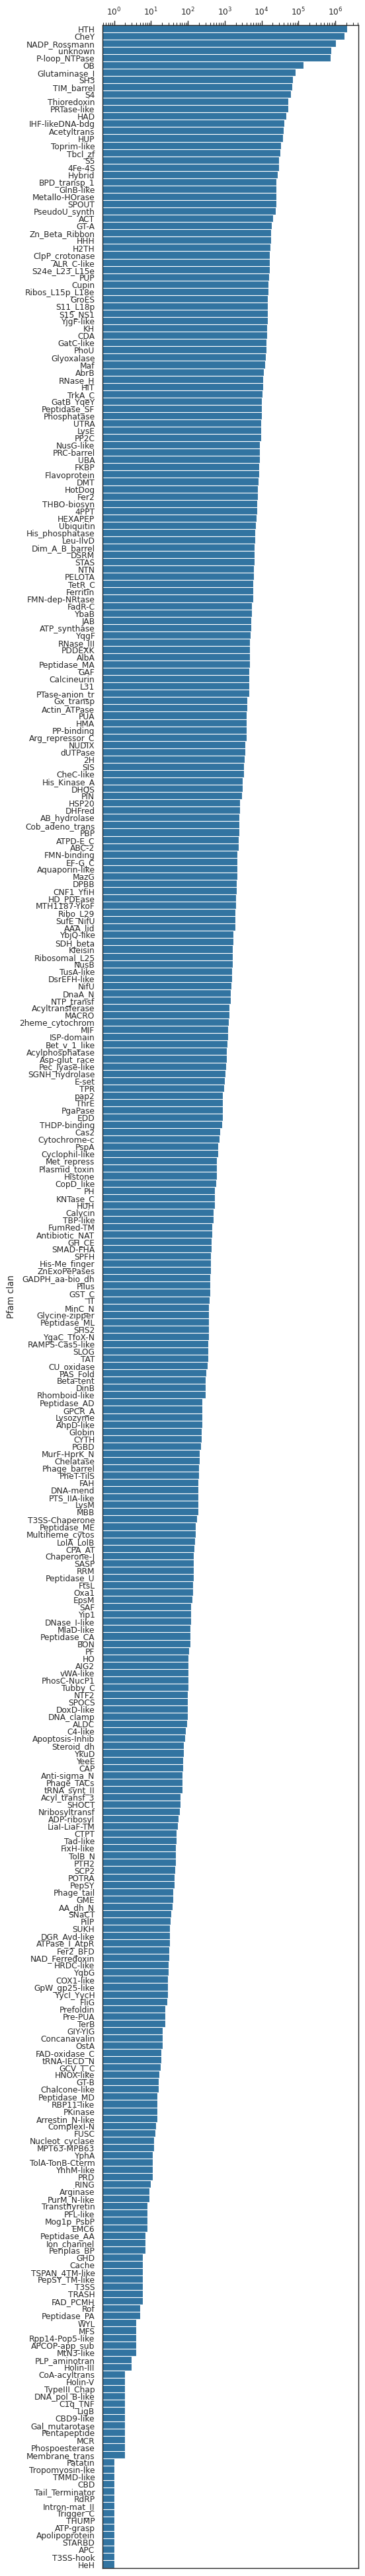

In [99]:
fig, ax = plt.subplots(figsize=(5,50))
sns.set_context('paper')
g = sns.barplot(
    y=names,
    x=list(clan_counts.values),
    width=1
)
g.set_xscale('log')
ax.xaxis.tick_top()
ax.set_ylabel('Pfam clan')
plt.savefig('clan_counts.png', bbox_inches='tight', dpi=300)

## Load all test metrics and join into a datafram with Pfam

We lost the indexes so we need to retrieve them in the same way we did to run prediction

First load beam prediction and has the meso and thermo. Then map back to the test set to get index. Then map pfam. Repeat hashing to get structural data. Repeat again to get per sequence metrics.

In [73]:
query_pfams = pd.read_parquet('../data/index_to_pfam.parquet')

In [74]:
import hashlib
import json

In [75]:
test_set = ds['test']

In [76]:
hash_to_index = {}
for example in test_set:
    json_str = json.dumps((example['meso_seq'], example['thermo_seq']), sort_keys=True)
    hash_ = hashlib.sha256(json_str.encode()).hexdigest()
    hash_to_index[hash_] = example['index']

In [77]:
# load the predictions tsv and confirm sequences match
beam_predictions = pd.read_csv('../data/nomelt-model/predictions.tsv', sep='\t')

In [78]:
# map back to examples
indexes_list = []
hash_list = []
for _, row in beam_predictions.iterrows():
    json_str = json.dumps((row['input'], row['label']), sort_keys=True)
    hash_ = hashlib.sha256(json_str.encode()).hexdigest()
    
    try:
        index = hash_to_index[hash_]
    except:
        index = None

    indexes_list.append(index)
    hash_list.append(hash_)

In [79]:
beam_predictions['index'] = indexes_list
beam_predictions['hash'] = hash_list

In [80]:
beam_predictions['index'] = beam_predictions['index'].astype(pd.Int64Dtype())

get the mAF scores for the first 50

In [81]:
with open('../data/thermo_gen_estimated.json', 'r') as f:
    mafscores = json.load(f)

In [82]:
gmts = []
gmms = []
for i in range(50):
    gmms.append(mafscores[f'trans_{i}'][0] - mafscores[f'meso_{i}'][0])
    gmts.append(mafscores[f'trans_{i}'][0] - mafscores[f'thermo_{i}'][0])

In [83]:
example_subset = beam_predictions.iloc[:50]

In [84]:
length_diffs = [len(row['prediction']) - len(row['label']) for _, row in example_subset.iterrows()]

In [85]:
from scipy import stats

In [86]:
stats.spearmanr(np.abs(length_diffs), gmts)

SignificanceResult(statistic=0.02418006768868214, pvalue=0.8676229122935103)

### Map pfams

In [87]:
# map pfams
beam_predictions['pfams'] = beam_predictions['index'].map(lambda i: query_pfams['pfam_domains'].get(int(i) if not pd.isna(i) else None, None))
    

In [88]:
beam_predictions[beam_predictions['pfams'].isna()]

,input,prediction,label,index,hash,pfams
2,MTINQDLYEAIKKNNNMITTAQVLALGYSKQLLTNYVKAGLLERSR...,MKKEILELFEKNNGIITTKEAEELGIHRRTLSNYVKKGILERIGRG...,MQNVIDIFKQHYGYAYLKDLKAQGIHTDTIRKLLTGGKIEKIKPGL...,2162484,dfac9b0002d45cdfea06919d018d82fb25cd4c20445098...,None
4,MELQHYQQWISEFYKKRGLYALNSFIRVSFLSEETGEVARAVRALE...,MDIKEYQKLVDEYYKEKGWYKFSPFIRLAFLAEEVGELARAVRALE...,MDLKEVQELTDKWVSQFKEGYFPPMSLVVRLAEEVGELAREVNHRF...,1597539,1f915a697fc0aadf3899ced3d23d2db9c34ddd1e6d9504...,None
6,MNNGQFAFLIRHELKLESCKRFARSWYWIYIAAVAVVLFVAVAIWG...,MNNRQLLFLIRHELKLERRKRFARSWYWIYIAAVAVVLFVAVAIWG...,MAAQSNFWALVKHDFKRRKRRNMQIPKGWWLAYAGGALAVLLTLTT...,385062,51327b480e513a69e55462005a04de99511ead2e6d6cbd...,None
7,MVFYLISLFVIAIDQLSKGWIRANLAMGEETSVWSGLIHVIRLENT...,MAYYWIALAVIVLDQLTKWLVVRYMRLGESIPVIDNVLYITSHRNR...,MVYFLLLSFGFFLLDQLSKYFIIKNFALGQSVKILSFFSITHVKNP...,1591044,4e9490a574c2df18487eaca086b9458e62e39d1c833e71...,None
9,MLNKLKTNNGLTLIELLFTLAMFGVIVIWVTGLLINTAVINRKSEQ...,MKNNKGFTLIEVIVSLAILSIIAISFIPLFTQSIKLSKQSEDIITA...,MINLINNKRGVTLIEILLTLTILGIIIIPLTNLFVNTVKNNKRSED...,3192859,70ac95140aeb06d23dd0b1653a5187e3488593386062e1...,None
...,...,...,...,...,...,...
976,MYNNDGILIKGNKDGINTTINMNKFACFDDMLVLLIKKLSKGKHFY...,MKEPVVLKGIGKGIAVILDSGCDFETICNYFEKKIKSGKNFFSGAE...,MNEPVVLKGFGKGIAVILDSSCDFDIICDYFKQKVINGKNFFSGYE...,2886643,78151ee0f14b869172f04f383c1efaf70039fdea428e3f...,None
998,MLKLILIVCIFIISTYIGFAYGETFKKRQEQLKEILKSLTILQNDI...,MLKLIGAALIIISCTMIGFEKAREYSLRPQQLRQLQTALQALESEI...,MTLKLLGAALTVLAPSWIGFQIAARYARRPAELRGFQNGLAVLVTE...,1358994,a3d78a4656f842eff417d418b9d73e8d5e632d53baa488...,None
1000,MRLLVGLGNPGGEYELTRHNVGFIFTDYLADRHGISLKNEKKWDAE...,MKLFVGLGNPGKEYEETRHNVGFMVIDELARRWNVSYNQAKFHGIF...,MAKLIVGLGNPGPRYAATRHNAGWMLLDAFARKHGVAIEQRGFEGL...,4267136,08500d0db9ba2868f02f884630e5c0b411bafddf28eba9...,None
1002,MSTAWGAHDTEPTRLLLLRHGQTPWSVERRFAGREDIPLTEDGHAQ...,MTTRLYIARHGQSEWNLHNKMQGVQDIDLTPTGLKQAELLASRLKN...,MTKVILVRHGQTRWNLEQKYQGHTDIELTELGIRQAQLVAERLASE...,2480532,8e5f4b271552490589837263b1d15a570c8c5586ba2eba...,None


In [89]:
for index in ds['train']['index']:
    if index not in d:
        break

In [90]:
len(ds['train']) + len(ds['eval']) + len(ds['test'])

4715506

In [91]:
len(query_pfams)

4662646

In [92]:
len(ds['train']) + len(ds['eval']) + len(ds['test']) - len(query_pfams)

52860

In [93]:
ds

DatasetDict({
    train: Dataset({
        features: ['meso_seq', 'thermo_seq', 'taxid', 'query_align_cov', 'subject_align_cov', 'bit_score', 'scaled_local_symmetric_percent_id', 'meso_seq_len', 'thermo_seq_len', 'seq_len_diff', 'meso_temp', 'thermo_temp', 'index', 'unique_seq_hash', 'cluster'],
        num_rows: 4013789
    })
    eval: Dataset({
        features: ['meso_seq', 'thermo_seq', 'taxid', 'query_align_cov', 'subject_align_cov', 'bit_score', 'scaled_local_symmetric_percent_id', 'meso_seq_len', 'thermo_seq_len', 'seq_len_diff', 'meso_temp', 'thermo_temp', 'index', 'unique_seq_hash', 'cluster'],
        num_rows: 303577
    })
    test: Dataset({
        features: ['meso_seq', 'thermo_seq', 'taxid', 'query_align_cov', 'subject_align_cov', 'bit_score', 'scaled_local_symmetric_percent_id', 'meso_seq_len', 'thermo_seq_len', 'seq_len_diff', 'meso_temp', 'thermo_temp', 'index', 'unique_seq_hash', 'cluster'],
        num_rows: 398140
    })
})

In [94]:
pfams_in_test_set = []
for pfs in beam_predictions['pfams'].values:
    if not pfs:
        continue
    for pf in pfs.split(';'):
        pfams_in_test_set.append(pf)
pfams_in_test_set = set(pfams_in_test_set)
len(pfams_in_test_set)

479

In [95]:
beam_predictions['pfams'].isna().sum()

355

### Map structural data

In [96]:
structural_data = pd.read_csv('../data/nomelt-model/structure_analysis_results.csv')

In [97]:
beam_predictions = beam_predictions.set_index('hash', drop=True)

In [98]:
hashes_ = []
for _, row in structural_data.iterrows():
    json_str = json.dumps((row['meso_sequence'], row['thermo_sequence']), sort_keys=True)
    hash_ = hashlib.sha256(json_str.encode()).hexdigest()
    hashes_.append(hash_)

In [99]:
structural_data['hash'] = hashes_
structural_data = structural_data.set_index('hash', drop=True)

In [100]:
beam_predictions = structural_data.join(beam_predictions)

In [101]:
beam_predictions

,Unnamed: 0,meso_sequence,thermo_sequence,generated_sequence,thermo_pdb,generated_pdb,thermo_dssp,generated_dssp,js_divergence,thermo_ss_distribution,generated_ss_distribution,fatcat_pvalue,input,prediction,label,index,pfams
hash,,,,,,,,,,,,,,,,,
00b877fd2a096d6f91d6aab9efbf55e878c22b9f587d5a07b23d439f24a7cfb4,872,MNKWKVIAIIVCLLIIGYIGFTYFQIKQVANEKPPKNVPYLIILGA...,MLKRIIITAVLVVIITTGLMYGYIEWYGRNLEPGSADVIIVLGAAV...,MKKWLKRLLLLLLLLLLLLGGYVGYVYAQIERAAREKPPQKADVAI...,./tmp/alphafold_downloads/A0A0C7NGA8.pdb,./tmp/esmfold_predicts/structure_872.pdb,-HHHHHHHHHHHHHHHHHHHHHHHHHHHHH-------EEEE----E...,-HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH--------EEE...,0.002284,"{'-': 0.3064516129032258, 'H': 0.5215053763440...","{'-': 0.26804123711340205, 'H': 0.577319587628...",0.000000,MNKWKVIAIIVCLLIIGYIGFTYFQIKQVANEKPPKNVPYLIILGA...,MKKWLKRLLLLLLLLLLLLGGYVGYVYAQIERAAREKPPQKADVAI...,MLKRIIITAVLVVIITTGLMYGYIEWYGRNLEPGSADVIIVLGAAV...,3101938,PF02698.20
00e19abcf8195c4722a941c46442f2d135150e5e6b73fcc1eb28caf15013c1a8,526,MAVQHKAYQYRIFPNKQQQTFMAQSFGCSRFVFNHFLEKIKNRDEE...,MLVNKAYWYELKPNKTQLILLKKHAGCARFAWNWGLAERKRLWEEE...,MIKAYKYRIYPNKEQEILFAKTFGCVRFVYNKMLHDRIEHYKKTGK...,./tmp/alphafold_downloads/A0A1Z5HWL5.pdb,./tmp/esmfold_predicts/structure_526.pdb,-EEEEEEEEEEE--HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH...,-EEEEEEEEE--HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH--...,0.002277,"{'-': 0.38071065989847713, 'E': 0.279187817258...","{'-': 0.4031413612565445, 'E': 0.2303664921465...",0.000000,MAVQHKAYQYRIFPNKQQQTFMAQSFGCSRFVFNHFLEKIKNRDEE...,MIKAYKYRIYPNKEQEILFAKTFGCVRFVYNKMLHDRIEHYKKTGK...,MLVNKAYWYELKPNKTQLILLKKHAGCARFAWNWGLAERKRLWEEE...,2972942,PF12323.11
00ff8adad1a51951887e22d4d43c66de39dffa17230e0774e83392df1f61e345,790,MYQEKIYRTDVLNKMGHVFERFRFVIRSRSLSKEQMKTIDYHLSEI...,MYPTRTSMHELLVRMDHVFERIRILGRTRALRKDEIEEIDRHLTEI...,MYQEKIYRTDVLNKMGHVFERFRFVIRSRSLSKEQMKTIDYHLSEI...,./tmp/alphafold_downloads/D9PTZ1.pdb,./tmp/esmfold_predicts/structure_790.pdb,-------HHHHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHH...,-HHHHHHHHHHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHH...,0.018813,"{'-': 0.25925925925925924, 'H': 0.740740740740...","{'-': 0.1320754716981132, 'H': 0.8679245283018...",0.000004,MYQEKIYRTDVLNKMGHVFERFRFVIRSRSLSKEQMKTIDYHLSEI...,MYQEKIYRTDVLNKMGHVFERFRFVIRSRSLSKEQMKTIDYHLSEI...,MYPTRTSMHELLVRMDHVFERIRILGRTRALRKDEIEEIDRHLTEI...,4219952,None
0123e0a6adbfc47f380ddc3e0fcc877778b1ddb1731909a83b2c4c9c41b75f19,374,MTRFALTLEYDGGPFMGLQRQAHGPSVQQHVEEAVAAITGEEVIMH...,MRNIKIVLEYDGTNYAGWQRQKNALSIQQVVEEALYKLTKERITVI...,MRNILLTIEYDGTGYFGWQKQPNKKTIQGTIEEAIKKLTGEEVNLI...,./tmp/alphafold_downloads/A0A1I5TX84.pdb,./tmp/esmfold_predicts/structure_374.pdb,-EEEEEEEEE-HHH------------HHHHHHHHHHHHH------E...,-EEEEEEEEE-HHH------------HHHHHHHHHHHHH------E...,0.000102,"{'-': 0.45714285714285713, 'E': 0.277551020408...","{'-': 0.44672131147540983, 'E': 0.278688524590...",0.000000,MTRFALTLEYDGGPFMGLQRQAHGPSVQQHVEEAVAAITGEEVIMH...,MRNILLTIEYDGTGYFGWQKQPNKKTIQGTIEEAIKKLTGEEVNLI...,MRNIKIVLEYDGTNYAGWQRQKNALSIQQVVEEALYKLTKERITVI...,1565808,None
0137daaa6e2ab293b6f658c70fe3797bc464713fe20c9b11f8b0699d40fadfcd,345,MSWHVKTFQDLSPHKWYEIAKLRSDVFIVEQTSAYHEFDDLDQQSL...,MNIAIGTTQDRALYEDALRVRRLVFIEEQNVPEDEEIDAFEDDSFH...,MEWKIKHFNELTTNALYEIIKQRINVFVVEQKCPYFECDDKDLDSY...,./tmp/alphafold_downloads/Q5L1N2.pdb,./tmp/esmfold_predicts/structure_345.pdb,-EEEEE----HHHHHHHHHHHHHHH-------HHHH-------EEE...,-EEEEEEHHH--HHHHHHHHHHHHHHH------------HHHHH-E...,0.000717,"{'-': 0.3263888888888889, 'E': 0.3541666666666...","{'-': 0.3443708609271523, 'E': 0.3245033112582...",0.000000,MSWHVKTFQDLSPHKWYEIAKLRSDVFIVEQTSAYHEFDDLDQQSL...,MEWKIKHFNELTTNALYEIIKQRINVFVVEQKCPYFECDDKDLDSY...,MNIAIGTTQDRALYEDALRVRRLVFIEEQNVPEDEEIDAFEDDSFH...,1202232,PF00583.28;PF13508.10;PF13527.10;PF13673.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ff651f6444622aac4f284a07723adec62d7e865cc8a3e4b649abe6113e16d9e6,398,MLKNVPNKQAALYLQVKEVLIQRIQDKVWTPGNLIPTEQELMQEFD...,MGKSLNPHSVIPLYHQLKEILKENIESGVWKPGDRIPSENELRKQY...,MKKVSKQNPLPLYYQLKEILQEMIENEVLKPGDPIPPER

### Map sequence metrics

In [102]:
from Bio import pairwise2
from Bio.Align import substitution_matrices
from tqdm import tqdm

def global_alignment(seq1, seq2):
    matrix = substitution_matrices.load("BLOSUM62")
    alignments = pairwise2.align.globaldx(seq1, seq2, matrix)
    best_alignment = alignments[0]
    return best_alignment

def calculate_identity(seq1, seq2):
    identical = sum(el1 == el2 for el1, el2 in zip(seq1, seq2))
    return (identical / ((len(seq1) + len(seq2))/2))

def calculate_bpr(score, length):
    return score / length

def compute_alignment_metrics(seq1, seq2):
    aligned_seq1, aligned_seq2, score, begin, end = global_alignment(seq1, seq2)
    identity = calculate_identity(aligned_seq1, aligned_seq2)
    alignment_length = end - begin
    bpr = calculate_bpr(score, alignment_length)
    
    return {
        'seq1': aligned_seq1,
        'seq2': aligned_seq2,
        'score': score,
        'begin': begin,
        'end': end,
        'identity': identity,
        'bpr': bpr
    }

/mmfs1/gscratch/cheme/usr/evankomp/mamba/mambaforge/envs/nomelt_rebuild/lib/python3.9/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [103]:
pids = []
bprs = []
for _, row in beam_predictions.iterrows():
    metrics = compute_alignment_metrics(row['thermo_sequence'], row['generated_sequence'])
    pids.append(metrics['identity'])
    bprs.append(metrics['bpr'])

In [104]:
beam_predictions['pid'] = pids
beam_predictions['bpr'] = bprs

In [105]:
beam_predictions = beam_predictions[[
    'meso_sequence', 'thermo_sequence', 'generated_sequence',
    'js_divergence', 'fatcat_pvalue', 'index', 'pfams', 'pid', 'bpr', 'thermo_dssp'
]]

In [106]:
beam_predictions

,meso_sequence,thermo_sequence,generated_sequence,js_divergence,fatcat_pvalue,index,pfams,pid,bpr,thermo_dssp
hash,,,,,,,,,,
00b877fd2a096d6f91d6aab9efbf55e878c22b9f587d5a07b23d439f24a7cfb4,MNKWKVIAIIVCLLIIGYIGFTYFQIKQVANEKPPKNVPYLIILGA...,MLKRIIITAVLVVIITTGLMYGYIEWYGRNLEPGSADVIIVLGAAV...,MKKWLKRLLLLLLLLLLLLGGYVGYVYAQIERAAREKPPQKADVAI...,0.002284,0.000000,3101938,PF02698.20,0.365759,2.027237,-HHHHHHHHHHHHHHHHHHHHHHHHHHHHH-------EEEE----E...
00e19abcf8195c4722a941c46442f2d135150e5e6b73fcc1eb28caf15013c1a8,MAVQHKAYQYRIFPNKQQQTFMAQSFGCSRFVFNHFLEKIKNRDEE...,MLVNKAYWYELKPNKTQLILLKKHAGCARFAWNWGLAERKRLWEEE...,MIKAYKYRIYPNKEQEILFAKTFGCVRFVYNKMLHDRIEHYKKTGK...,0.002277,0.000000,2972942,PF12323.11,0.335821,1.966418,-EEEEEEEEEEE--HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH...
00ff8adad1a51951887e22d4d43c66de39dffa17230e0774e83392df1f61e345,MYQEKIYRTDVLNKMGHVFERFRFVIRSRSLSKEQMKTIDYHLSEI...,MYPTRTSMHELLVRMDHVFERIRILGRTRALRKDEIEEIDRHLTEI...,MYQEKIYRTDVLNKMGHVFERFRFVIRSRSLSKEQMKTIDYHLSEI...,0.018813,0.000004,4219952,None,0.391304,2.289855,-------HHHHHHHHHHHHHHHHHHHH-----HHHHHHHHHHHHHH...
0123e0a6adbfc47f380ddc3e0fcc877778b1ddb1731909a83b2c4c9c41b75f19,MTRFALTLEYDGGPFMGLQRQAHGPSVQQHVEEAVAAITGEEVIMH...,MRNIKIVLEYDGTNYAGWQRQKNALSIQQVVEEALYKLTKERITVI...,MRNILLTIEYDGTGYFGWQKQPNKKTIQGTIEEAIKKLTGEEVNLI...,0.000102,0.000000,1565808,None,0.409786,2.327217,-EEEEEEEEE-HHH------------HHHHHHHHHHHHH------E...
0137daaa6e2ab293b6f658c70fe3797bc464713fe20c9b11f8b0699d40fadfcd,MSWHVKTFQDLSPHKWYEIAKLRSDVFIVEQTSAYHEFDDLDQQSL...,MNIAIGTTQDRALYEDALRVRRLVFIEEQNVPEDEEIDAFEDDSFH...,MEWKIKHFNELTTNALYEIIKQRINVFVVEQKCPYFECDDKDLDSY...,0.000717,0.000000,1202232,PF00583.28;PF13508.10;PF13527.10;PF13673.10,0.317308,1.884615,-EEEEE----HHHHHHHHHHHHHHH-------HHHH-------EEE...
...,...,...,...,...,...,...,...,...,...,...
ff651f6444622aac4f284a07723adec62d7e865cc8a3e4b649abe6113e16d9e6,MLKNVPNKQAALYLQVKEVLIQRIQDKVWTPGNLIPTEQELMQEFD...,MGKSLNPHSVIPLYHQLKEILKENIESGVWKPGDRIPSENELRKQY...,MKKVSKQNPLPLYYQLKEILQEMIENEVLKPGDPIPPERELCEIHG...,0.000086,0.000000,3690560,None,0.356287,1.988024,------------HHHHHHHHHHHHHH--------E---HHHHHHHH...
ff6e04918cf9cfb6dca1f0883c10e5dfa8848ab29f26eddfed9110e753ae2cfb,MELELKEYAQIVKKKLWLILFIVILVGSTTGIYSYLFVQPKYEASN...,MEETISLRELFDTLRKRLWLIVLITALATVVSGVVSYFILTPIYEA...,MEEEIDLRELFLILRKRIKLIVLITLLATLISGIVSYFILTPIYKA...,0.002353,0.000000,1322347,PF02706.18,0.472973,2.537162,------HHHHHHHHHH-HHHHHHHHHHHHHHHHHHHHH----EEEE...
ff7524293cf4ba99ecb4de0e5b62985206503ec80d67762dec0740dcf5131df1,MDLSVLHKLTYGMYAVGTLDGIRPAGCIVNTVIQVTSDNPVIAVSM...,MDIKALHTISYGLYVVTAKKDNRFNGQVANTVFQISSEPPTVAVSI...,MDLNALRKIPYGLYVVGTKDGDKVNAMTANWVMQVSFEPPLVAVSV...,0.002679,0.000000,3092371,PF01613.21,0.433213,2.519856,--HHHHHH---E-EEEEEEE--EEEEEEE--EEE-EE--EEEEEEE...


In [107]:
beam_predictions.to_csv('test_scores_all_per_example.csv')

In [108]:
beam_predictions.describe()

,js_divergence,fatcat_pvalue,index,pid,bpr
count,1018.000000,1.018000e+03,1.008000e+03,1018.000000,1018.000000
mean,0.009665,1.328312e-02,2.311550e+06,0.429481,2.402870
std,0.045792,1.001969e-01,1.342971e+06,0.193050,0.944249
min,0.000000,0.000000e+00,3.024000e+03,0.045326,0.269231
25%,0.000250,0.000000e+00,1.210796e+06,0.318221,1.857743
50%,0.000875,0.000000e+00,2.379229e+06,0.376289,2.152727
75%,0.002384,1.972500e-15,3.382655e+06,0.468875,2.661017
max,0.497909,9.950000e-01,4.709561e+06,1.000000,5.333333


In [112]:
beam_predictions['beta_sheet_frac'] = beam_predictions['thermo_dssp'].apply(lambda s: np.mean([s_ == 'E' for s_ in s]))

/tmp/ipykernel_83962/1910226138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  beam_predictions['beta_sheet_frac'] = beam_predictions['thermo_dssp'].apply(lambda s: np.mean([s_ == 'E' for s_ in s]))


In [116]:
mostly_sheet = beam_predictions[beam_predictions['beta_sheet_frac'] > 0.5]
not_sheet = beam_predictions[beam_predictions['beta_sheet_frac'] < 0.5]

In [118]:
mostly_sheet.describe()

,js_divergence,fatcat_pvalue,index,pid,bpr,beta_sheet_frac
count,9.000000,9.000000e+00,9.000000e+00,9.000000,9.000000,9.000000
mean,0.002840,6.982222e-13,2.707340e+06,0.567600,3.137876,0.557342
std,0.004086,1.765339e-12,1.189624e+06,0.239912,1.175168,0.073727
min,0.000000,0.000000e+00,8.092630e+05,0.323529,1.858824,0.504386
25%,0.000269,0.000000e+00,1.753133e+06,0.375887,2.269504,0.519685
50%,0.001578,0.000000e+00,2.887180e+06,0.469027,2.765487,0.529412
75%,0.003396,0.000000e+00,3.698572e+06,0.767241,4.112069,0.560748
max,0.012998,5.330000e-12,4.192802e+06,1.000000,5.164773,0.744828


In [119]:
(beam_predictions['beta_sheet_frac'] > 0.1).sum()

744

## Map test scores to pfam values and aggregate, to show family dependency

In [182]:
beam_predictions.dropna()

,hash,meso_sequence,thermo_sequence,generated_sequence,js_divergence,fatcat_pvalue,index,pfams,pid,bpr
0,00b877fd2a096d6f91d6aab9efbf55e878c22b9f587d5a...,MNKWKVIAIIVCLLIIGYIGFTYFQIKQVANEKPPKNVPYLIILGA...,MLKRIIITAVLVVIITTGLMYGYIEWYGRNLEPGSADVIIVLGAAV...,MKKWLKRLLLLLLLLLLLLGGYVGYVYAQIERAAREKPPQKADVAI...,0.002284,0.000000e+00,3101938.0,PF02698.20,0.365759,2.027237
1,00e19abcf8195c4722a941c46442f2d135150e5e6b73fc...,MAVQHKAYQYRIFPNKQQQTFMAQSFGCSRFVFNHFLEKIKNRDEE...,MLVNKAYWYELKPNKTQLILLKKHAGCARFAWNWGLAERKRLWEEE...,MIKAYKYRIYPNKEQEILFAKTFGCVRFVYNKMLHDRIEHYKKTGK...,0.002277,0.000000e+00,2972942.0,PF12323.11,0.335821,1.966418
4,0137daaa6e2ab293b6f658c70fe3797bc464713fe20c9b...,MSWHVKTFQDLSPHKWYEIAKLRSDVFIVEQTSAYHEFDDLDQQSL...,MNIAIGTTQDRALYEDALRVRRLVFIEEQNVPEDEEIDAFEDDSFH...,MEWKIKHFNELTTNALYEIIKQRINVFVVEQKCPYFECDDKDLDSY...,0.000717,0.000000e+00,1202232.0,PF00583.28;PF13508.10;PF13527.10;PF13673.10,0.317308,1.884615
7,01f5ab08a427d54477b3b9229d1cc21232168927efb4fa...,MDFFQILSEDRIKKAYQDGEFNNLPGFGKPMKYEDLSGIPEELRMA...,MDILMHLAEERIREAMENGVFDNLPGKGQKIIPEDLSMIPEDLRAG...,MDILTIIAEEKIKEAMEKGEFDNLPGKGKPLDLEDLSHVPEELRAG...,0.002802,1.200000e-09,1607862.0,PF09350.13,0.591549,3.302817
8,0237329568971757631d094130cb4620a80dbc50bd4d7b...,MEKREYTCIVCPKSCKGTLSIADDGGMTTEGFDCKNGKQYAQDEYT...,MEVKEITCIVCPLGCRIKVEMEGGEIKSIKGYSCPKGLEYAKNEVT...,MEKKELTCIVCPNGCRLVVEMEGEKIVNVTGYECKRGLEYAKNEVT...,0.000068,0.000000e+00,3452028.0,PF07892.14,0.659574,3.574468
...,...,...,...,...,...,...,...,...,...,...
1009,ff0005eb1e2ff1692136b4cc73a9d36dd3e7dc64b8e196...,MKLMKNYLKKASLILAVFFFIYGVASFLNDYLLQAEKIQGTSMEPL...,MSKNIGKEILSWIFTILLAFAIALFIRTYVFELVDVPTGSMMDTIH...,MAEGQKSYWQEIIESLVIAVILAVVIRAFILQPFYIPSGSMIPTLL...,0.000274,0.000000e+00,1107364.0,PF10502.12,0.400881,2.506608
1012,ff2d1c37ab6f5062f4f5faff2e43532ecafca0a248832c...,MLHRKKSALKTAGAEALPLAIAIAAYGMSYGVLATQVNFTLLTTVA...,MDKKSRIKAGLAEALPLAVAIAAYGLSYGVLAVQANLSVAEAVAMS...,MKEEIKKGIKDSIPIVLGYIPIGFAYGIIGKKSGFSILEIILMSIF...,0.001293,0.000000e+00,412919.0,PF03591.17,0.300654,1.924837
1014,ff6e04918cf9cfb6dca1f0883c10e5dfa8848ab29f26ed...,MELELKEYAQIVKKKLWLILFIVILVGSTTGIYSYLFVQPKYEASN...,MEETISLRELFDTLRKRLWLIVLITALATVVSGVVSYFILTPIYEA...,MEEEIDLRELFLILRKRIKLIVLITLLATLISGIVSYFILTPIYKA...,0.002353,0.000000e+00,1322347.0,PF02706.18,0.472973,2.537162
1015,ff7524293cf4ba99ecb4de0e5b62985206503ec80d6776...,MDLSVLHKLTYGMYAVGTLDGIRPAGCIVNTVIQVTSDNPVIAVSM...,MDIKALHTISYGLYVVTAKKDNRFNGQVANTVFQISSEPPTVAVSI...,MDLNALRKIPYGLYVVGTKDGDKVNAMTANWVMQVSFEPPLVAVSV...,0.002679,0.000000e+00,3092371.0,PF01613.21,0.433213,2.519856


In [185]:
melted = []
for _, row in beam_predictions.dropna().iterrows():
    for pf in row['pfams'].split(';'):
        melted.append({
            'pfam': pf,
            'pid': row['pid'],
            'bpr': row['bpr'],
            'fatcat': row['fatcat_pvalue'],
            'ss_divergence': row['js_divergence']
        })

In [187]:
per_family_metrics = pd.DataFrame(melted)
per_family_metrics = per_family_metrics.groupby('pfam').mean()

In [189]:
per_family_metrics

,pid,bpr,fatcat,ss_divergence
pfam,,,,
PF00005.30,0.379884,2.123111,0.000000e+00,0.001428
PF00011.24,0.381952,2.245619,3.442600e-07,0.021773
PF00027.32,0.377419,2.117069,1.945455e-14,0.000862
PF00034.24,0.212766,1.177305,5.390000e-01,0.051722
PF00035.29,0.702970,3.600207,0.000000e+00,0.000081
...,...,...,...,...
PF18765.4,0.466017,2.500812,0.000000e+00,0.001699
PF18856.4,0.548913,2.902174,2.710000e-13,0.000161
PF18912.3,0.679389,3.790076,0.000000e+00,0.000277


In [195]:
per_family_metrics['pfam_counts_in_dataset'] = per_family_metrics.index.map(pfam_counts['0'].to_dict())

In [197]:
per_family_metrics.to_csv('per_family_metrics.csv')

In [200]:
per_family_metrics['fatcat'] = np.log(per_family_metrics['fatcat'])

/mmfs1/gscratch/cheme/usr/evankomp/mamba/mambaforge/envs/nomelt_rebuild/lib/python3.9/site-packages/pandas/core/arraylike.py:405: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [202]:
per_family_metrics['pfam_counts_in_dataset'] = np.log(per_family_metrics['pfam_counts_in_dataset'])

In [205]:
per_family_metrics = per_family_metrics.rename(columns={
    'pfam_counts_in_dataset': 'log(count family in dataset)',
    'fatcat': 'log(fatcat pvalue)',
    'bpr': 'Bits per Residue (B62)',
    'pid': '%identity',
    'ss_divergence': 'Secondary structure divergence'
})

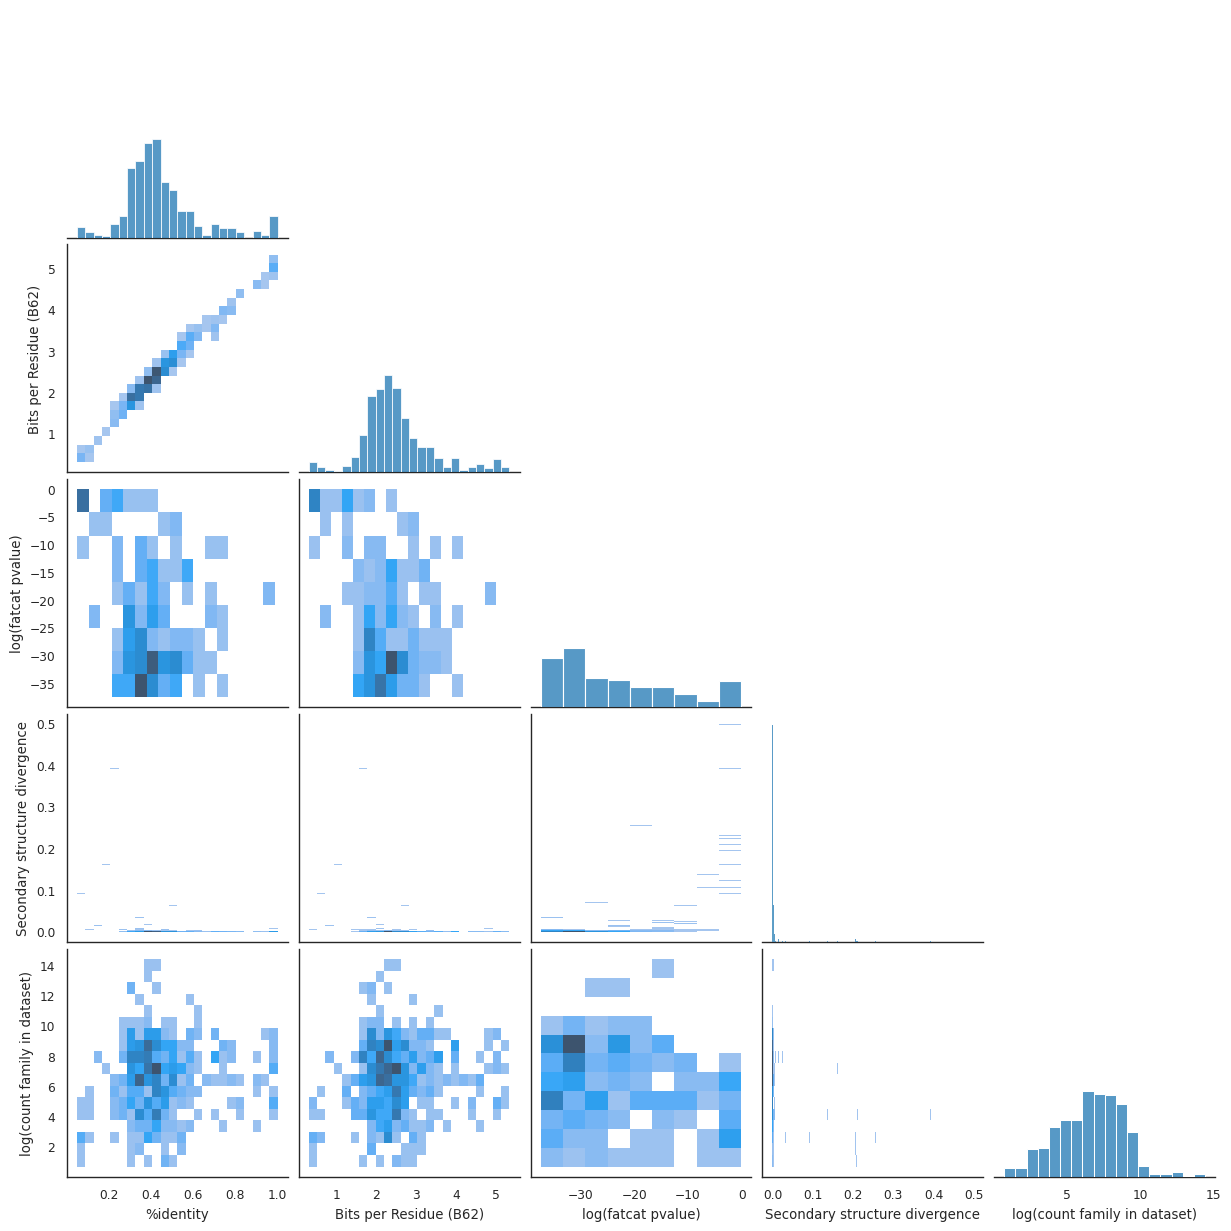

In [208]:
sns.pairplot(per_family_metrics, corner=True, diag_kind='hist', kind='hist')

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def create_pfam_correlation_plot(data, count_col='log(count family in dataset)', figsize=(12, 15)):
    # Get variables to plot against counts (excluding the count column itself)
    other_vars = [col for col in data.columns if col != count_col]
    n_rows = len(other_vars)
    
    # Create figure with extra height for the top distribution
    fig = plt.figure(figsize=figsize)
    
    # Create two GridSpec objects - one for the top histogram and one for the main plots
    gs_top = plt.GridSpec(1, 1, top=0.95, bottom=0.85, left=0.1, right=0.72)
    gs_main = plt.GridSpec(n_rows, 2, top=0.80, bottom=0.05, left=0.1, right=0.95,
                          width_ratios=[3, 1], hspace=0.4, wspace=0.05)
    
    # Create top distribution plot for pfam counts
    ax_top_dist = fig.add_subplot(gs_top[0])
    sns.histplot(data=data, x=count_col, ax=ax_top_dist)
    ax_top_dist.set_title('Distribution of Pfam Counts', pad=10)
    
    # Plot each correlation
    for idx, var in enumerate(other_vars):
        # Scatter plot with regression
        ax_scatter = fig.add_subplot(gs_main[idx, 0])
        
        # Calculate Spearman correlation and p-value
        corr, p_val = stats.spearmanr(data[count_col], data[var])
        
        # Create scatter plot
        sns.regplot(data=data, x=count_col, y=var, ax=ax_scatter,
                   scatter_kws={'alpha':0.5}, line_kws={'color': 'black'})
        
        # Add correlation info
        ax_scatter.text(0.05, 0.95, 
                       f'ρ = {corr:.2f}\np = {p_val:.2e}',
                       transform=ax_scatter.transAxes,
                       verticalalignment='top',
                       bbox=dict(facecolor='white', alpha=0.8))
        
        # Distribution plot for other variable
        ax_dist = fig.add_subplot(gs_main[idx, 1])
        sns.histplot(data=data, y=var, ax=ax_dist, bins=15)
        ax_dist.set_ylim(ax_scatter.get_ylim())
        
        # Remove redundant labels
        ax_dist.set_ylabel('')
        if idx < n_rows - 1:  # Only keep x label for bottom plot
            ax_scatter.set_xlabel('')
        
        # Remove y-ticks from distribution plot
        ax_dist.set_yticks([])
    
    # Add overall title
    fig.suptitle('Relationships between Pfam Counts and Metrics', y=0.98, fontsize=14)
    
    return fig

# Create the plot with adjusted figure size
fig = create_pfam_correlation_plot(per_family_metrics)
plt.savefig('pfam_correlations.png', dpi=300, bbox_inches='tight')
plt.close()

/mmfs1/gscratch/cheme/usr/evankomp/mamba/mambaforge/envs/nomelt_rebuild/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
